In [1]:
import os
import gc
import pickle
import itertools

import torch                        # import torch BEFORE cuML (nemi): CUDA/numba init order
import numpy as np
import pandas as pd
import psutil
from matplotlib import pyplot as plt
from IPython.display import display

from nemi import NEMI, SingleNemi
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import visualization.visualization as vis
from nemi import NEMI, SingleNemi    # cuML — must come after torch
from metrics import projection_metrics as pm
from metrics import kmeans_eval

try:
    import cupy as cp
except Exception:
    cp = None

try:
    import pynvml; pynvml.nvmlInit(); _NVML_HANDLE = pynvml.nvmlDeviceGetHandleByIndex(0)
except Exception:
    _NVML_HANDLE = None

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
source = cutouts_dataset.CutoutDataSource(bucket="dbof", folder="cutouts_dataset_v2",
                                          run_id="1_00",
                                          dataset_name="cutout_dataset.zarr",
                                          s3_endpoint="https://s3-west.nrp-nautilus.io"
                                          )

source.print_available_channels()

23 available channels:
['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl','SIarea','XC','YC']


In [3]:
#data_channels = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','coriolis_f','oceQnet','ekman_pumping','wind_stress_curl']
#data_channels_high_res = ['Salt','Theta','U','V','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','oceQnet','ekman_pumping','wind_stress_curl']
data_channels_no_cor = ['Eta','Salt','Theta','U','V','W','gradb2','oceTAUX','oceTAUY','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','oceQnet','ekman_pumping','wind_stress_curl']

data_channels_engineered = ['gradb2','gradrho2','turner_angle','strain_n','strain_s','strain_mag','divergence','relative_vorticity','oceQnet','ekman_pumping','wind_stress_curl']
dataset = cutouts_dataset.CutoutDataset.from_source(data_channels=data_channels_engineered, source=source, subset=False,
                                                    subsample_per_chunk=64, num_sample_chunks=1, n_workers=4)

/home/jovyan/conda_envs/main_cuml/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 40369 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:36753' processes=4 threads=32, memory=128.00 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/40369/status
dropped 0 ice, 0 NaN; kept 3250 / 3250
features ['gradb2', 'gradrho2', 'turner_angle', 'strain_n', 'strain_s', 'strain_mag', 'divergence', 'relative_vorticity', 'oceQnet', 'ekman_pumping', 'wind_stress_curl'] | coords ['XC', 'YC']


In [4]:
patch_size = 8
EMBEDDING_DIMENSIONS = 3
patches = dataset.get_patches(patch_size=patch_size)   # (N_patches, C_feat*p*p), coords excluded
print(patches.shape)

(208000, 704)


# Embedding only

In [5]:
# --- shared helpers -------------------------------------------------------
def _umap_configs(grid):
    """Full-factorial expansion of {param: [values]} -> dicts."""
    keys = list(grid)
    for vals in itertools.product(*(grid[k] for k in keys)):
        yield dict(zip(keys, vals))


def _free_gpu():
    """Drop references and return pooled GPU blocks between fits."""
    gc.collect()
    if cp is not None:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()


def _fit_embeddings(X, umap_params, n_components, device, n_runs):
    """Fit n_runs UMAP embeddings of X (embedding only, no clustering)."""
    embs = []
    for _ in range(n_runs):
        s = SingleNemi(params={"device": device,
                               "embedding_dict": {"n_components": n_components, **umap_params}})
        s.fit_embedding(X)
        embs.append(np.asarray(s.embedding))
        s = None
        _free_gpu()
    return embs


def _n_clusters(labels):
    """Cluster count, ignoring NaN/negative (-1) noise."""
    finite = np.asarray(labels, dtype=float)
    finite = finite[np.isfinite(finite)]
    finite = finite[finite >= 0]
    return int(finite.max()) + 1 if finite.size else 0


def gpu_used_gb():
    return pynvml.nvmlDeviceGetMemoryInfo(_NVML_HANDLE).used / 1e9 if _NVML_HANDLE is not None else float("nan")


def host_used_gb():
    return psutil.Process(os.getpid()).memory_info().rss / 1e9


# pod host memory cap (cgroup) -- context for the host_used_gb readings
try:    _host_cap = open("/sys/fs/cgroup/memory.max").read().strip()            # cgroup v2
except: _host_cap = open("/sys/fs/cgroup/memory/memory.limit_in_bytes").read()  # cgroup v1
print("host cap:", _host_cap)

host cap: 137438953472


In [6]:
def _cluster(embedding, clu_params, device):
    """Cluster an already-fitted embedding with NEMI's clusterer (no re-embedding).
    clu_params is a clustering_dict, e.g. {'method':'hdbscan','min_cluster_size':400}."""
    s = SingleNemi(params={"device": device, "clustering_dict": dict(clu_params)})
    s.embedding = np.asarray(embedding)
    return np.asarray(s.predict_clusters())


def _silhouette(embedding, labels, sample_size, seed):
    """Silhouette over the assigned points only; -1 noise is dropped rather than
    scored as a cluster."""
    keep = labels >= 0
    return kmeans_eval.silhouette(embedding[keep], labels[keep],
                                  sample_size=sample_size, seed=seed)


def run_embedding_sweep(patches, umap_grid, clustering_grid=None, *, n_runs=3,
                        n_components=3, device="gpu", sweep_size=50000,
                        metric_sample=3000, silhouette=False, k=pm.DEFAULT_K,
                        display_subsample=30000,
                        field=None, labels=None, save_path="embed_sweep.pkl",
                        seed=0, verbose=True):
    """Sweep UMAP params (embedding only) and, optionally, clustering params.

    Each UMAP config's embedding is fit once and scored with the projection metrics
    (trustworthiness, continuity, normalized_stress, and neighborhood_hit when
    ``labels`` is given).  If ``clustering_grid`` is given, every clustering config
    is run on that embedding and its cluster count + noise % recorded -- one result
    row per (UMAP x clustering) combination.

    clustering_grid MUST include 'method' (e.g. {'method':['hdbscan'],
    'min_cluster_size':[200,400], 'min_samples':[None]}).  None -> embedding only.

    silhouette : also score each clustering with the silhouette coefficient, over
    ``metric_sample`` points.  Needs labels, so it has no effect without a
    clustering_grid.

    Returns (results, panels).
    """
    rng = np.random.default_rng(seed)
    n = len(patches)
    fit_idx = (rng.choice(n, size=sweep_size, replace=False)
               if sweep_size and sweep_size < n else np.arange(n))
    Xfit  = patches[fit_idx]
    f_fit = None if field is None else np.asarray(field)[fit_idx]
    l_fit = None if labels is None else np.asarray(labels)[fit_idx]

    m_idx = rng.choice(len(Xfit), size=min(metric_sample, len(Xfit)), replace=False)
    Xm    = Xfit[m_idx]
    l_m   = None if l_fit is None else l_fit[m_idx]

    clu_configs = list(_umap_configs(clustering_grid)) if clustering_grid else [None]

    results, panels = [], []
    for umap_params in _umap_configs(umap_grid):
        print(f"GPU {gpu_used_gb():.2f}")
        if verbose:
            print(f"embedding {umap_params}")
        try:
            embs = _fit_embeddings(Xfit, umap_params, n_components, device, n_runs)
            E0   = embs[0]
            Em0  = E0[m_idx]

            proj = {"trustworthiness":   pm.trustworthiness(Xm, Em0, k),
                    "continuity":        pm.continuity(Xm, Em0, k),
                    "normalized_stress": pm.normalized_stress(Xm, Em0)}
            if l_m is not None:
                proj["neighborhood_hit"] = pm.neighborhood_hit(Em0, l_m, k)

            disp = (rng.choice(len(E0), size=min(len(E0), display_subsample), replace=False)
                    if display_subsample else slice(None))
            embs_disp = [e[disp] for e in embs]        # shared across clustering configs

            for clu_params in clu_configs:
                stat = {**umap_params, **(clu_params or {}), **proj}
                clusters_disp = None
                if clu_params is not None:
                    try:
                        lab = _cluster(E0, clu_params, device)
                        stat["n_clusters"] = _n_clusters(lab)
                        stat["noise_%"]    = 100 * float(np.mean(lab < 0))
                        if silhouette:
                            stat["silhouette"] = _silhouette(E0, lab, metric_sample, seed)
                        clusters_disp = lab[disp]
                    except Exception as e:
                        print(f"    clustering failed {clu_params}: {type(e).__name__}: {e}")
                    finally:
                        lab = None
                        _free_gpu()                    # <-- release GPU between clustering configs

                if verbose:
                    tag = "" if clu_params is None else f"{clu_params}  "
                    print("  " + tag + "  ".join(f"{kk}={vv:.3f}" for kk, vv in stat.items()
                                                 if isinstance(vv, float)))

                title = str(umap_params) + ("" if clu_params is None else f"\n{clu_params}")
                panels.append({"title": title,
                               "embs": embs_disp,                 # same object -> no copy
                               "field": None if f_fit is None else f_fit[disp],
                               "clusters": clusters_disp})
                results.append(stat)

            if save_path:
                with open(save_path, "wb") as fh:
                    pickle.dump({"results": results, "panels": panels}, fh)
        except Exception as e:
            print(f"  !! failed on {umap_params}: {type(e).__name__}: {e}")
        finally:
            _free_gpu()

    return results, panels

In [7]:
from sklearn.decomposition import PCA


def _frame_axes(ax, pts, dims, pct=1.0):
    """Clip axis limits to the central (100-2*pct)% per dim, so a few outliers
    don't zoom the whole cloud out.  pct<=0 disables."""
    if pct <= 0:
        return
    setters = [ax.set_xlim, ax.set_ylim] + ([ax.set_zlim] if dims == 3 else [])
    for d, setlim in enumerate(setters):
        lo, hi = np.percentile(pts[:, d], [pct, 100 - pct])
        if hi > lo:
            setlim(lo, hi)


def _view(e, dims):
    """Reduce an embedding to `dims` for DISPLAY ONLY -- PCA when it has more than
    `dims` components (e.g. an n_components sweep).  Metrics use the full embedding."""
    return PCA(n_components=dims).fit_transform(e) if e.shape[1] > dims else e


_SHORT = {"trustworthiness": "trust", "continuity": "cont",
          "normalized_stress": "stress", "neighborhood_hit": "nh",
          "n_clusters": "k", "noise_%": "noise%", "silhouette": "sil"}


def _row_label(p, res):
    parts = [(f"{s}={res[n]:.0f}" if n == "n_clusters" else f"{s}={res[n]:.2f}")
             for n, s in _SHORT.items() if n in res]
    return f"{p['title']}\n" + "  ".join(parts) if parts else p["title"]


def show_embedding_sweep(results, panels, *, dims=3, sort_by=None,
                         point_size=2, alpha=0.5, panel_size=4.5, clip_pct=1.0):
    """Grid of swept embeddings: one ROW per config, one COLUMN per ensemble member.

    Colouring: by cluster labels (discrete, -1 grey) when a panel has them,
    else by ``field`` (continuous), else plain.  Embeddings with more than `dims`
    components are PCA-reduced to `dims` for display only.  clip_pct clips each
    axis to that percentile range (0 = off)."""
    proj   = "3d" if dims == 3 else None
    n_runs = max(len(p["embs"]) for p in panels)
    n_rows = len(panels)

    fig, axes = plt.subplots(n_rows, n_runs, squeeze=False,
                             figsize=(panel_size * n_runs, panel_size * n_rows),
                             subplot_kw={"projection": proj})
    fig.subplots_adjust(left=0.26, hspace=0.15, wspace=0.05)

    for r, (p, res) in enumerate(zip(panels, results)):
        clusters = p.get("clusters")
        field    = p.get("field")
        if clusters is not None:
            color, cmap, norm = clusters, *vis._cluster_cmap_norm(clusters)
        elif field is not None:
            color, cmap, norm = field, "viridis", None
        else:
            color, cmap, norm = None, None, None

        sc = None
        for j, e in enumerate(p["embs"]):
            ev = _view(e, dims)                       # PCA -> dims for display only
            ax = axes[r][j]
            sc = ax.scatter(*[ev[:, d] for d in range(dims)], c=color, cmap=cmap, norm=norm,
                            s=point_size, alpha=alpha, linewidths=0)
            _frame_axes(ax, ev, dims, clip_pct)
            if r == 0:
                ax.set_title(f"run {j}", fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
            if dims == 3:
                ax.set_zticks([])

        # colourbar only for the continuous field case
        if field is not None and clusters is None and sc is not None:
            fig.colorbar(sc, ax=axes[r][n_runs - 1], fraction=0.046, pad=0.02)

        pos = axes[r][0].get_position()
        fig.text(0.02, pos.y0 + pos.height / 2, _row_label(p, res),
                 ha="left", va="center", fontsize=9, family="monospace")

    plt.show()

    df = pd.DataFrame(results)
    if sort_by and sort_by in df.columns:
        df = df.sort_values(sort_by, ascending=False).reset_index(drop=True)
    display(df.round(3))
    return df

GPU 1.95
embedding {'n_neighbors': 50, 'min_dist': 0.0, 'metric': 'euclidean', 'n_components': 3}
[2026-07-30 16:12:14.630] [CUML] [info] Building knn graph using nn descent
[2026-07-30 16:12:16.963] [CUML] [warning] Spectral initialization failed, using random initialization instead.
[2026-07-30 16:12:18.967] [CUML] [info] Building knn graph using nn descent
[2026-07-30 16:12:21.196] [CUML] [warning] Spectral initialization failed, using random initialization instead.
[2026-07-30 16:12:23.178] [CUML] [info] Building knn graph using nn descent
[2026-07-30 16:12:25.419] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Clustering | device=gpu | {'method': 'kmeans', 'n_clusters': 10}
Clusters found: 10
silhouette on 3,000 / 208,000 samples
  {'method': 'kmeans', 'n_clusters': 10}  min_dist=0.000  trustworthiness=0.812  continuity=0.935  normalized_stress=0.212  noise_%=0.000  silhouette=0.322
GPU 1.95
embedding {'n_neighbors': 60, 'min_dist': 0.0, 'met

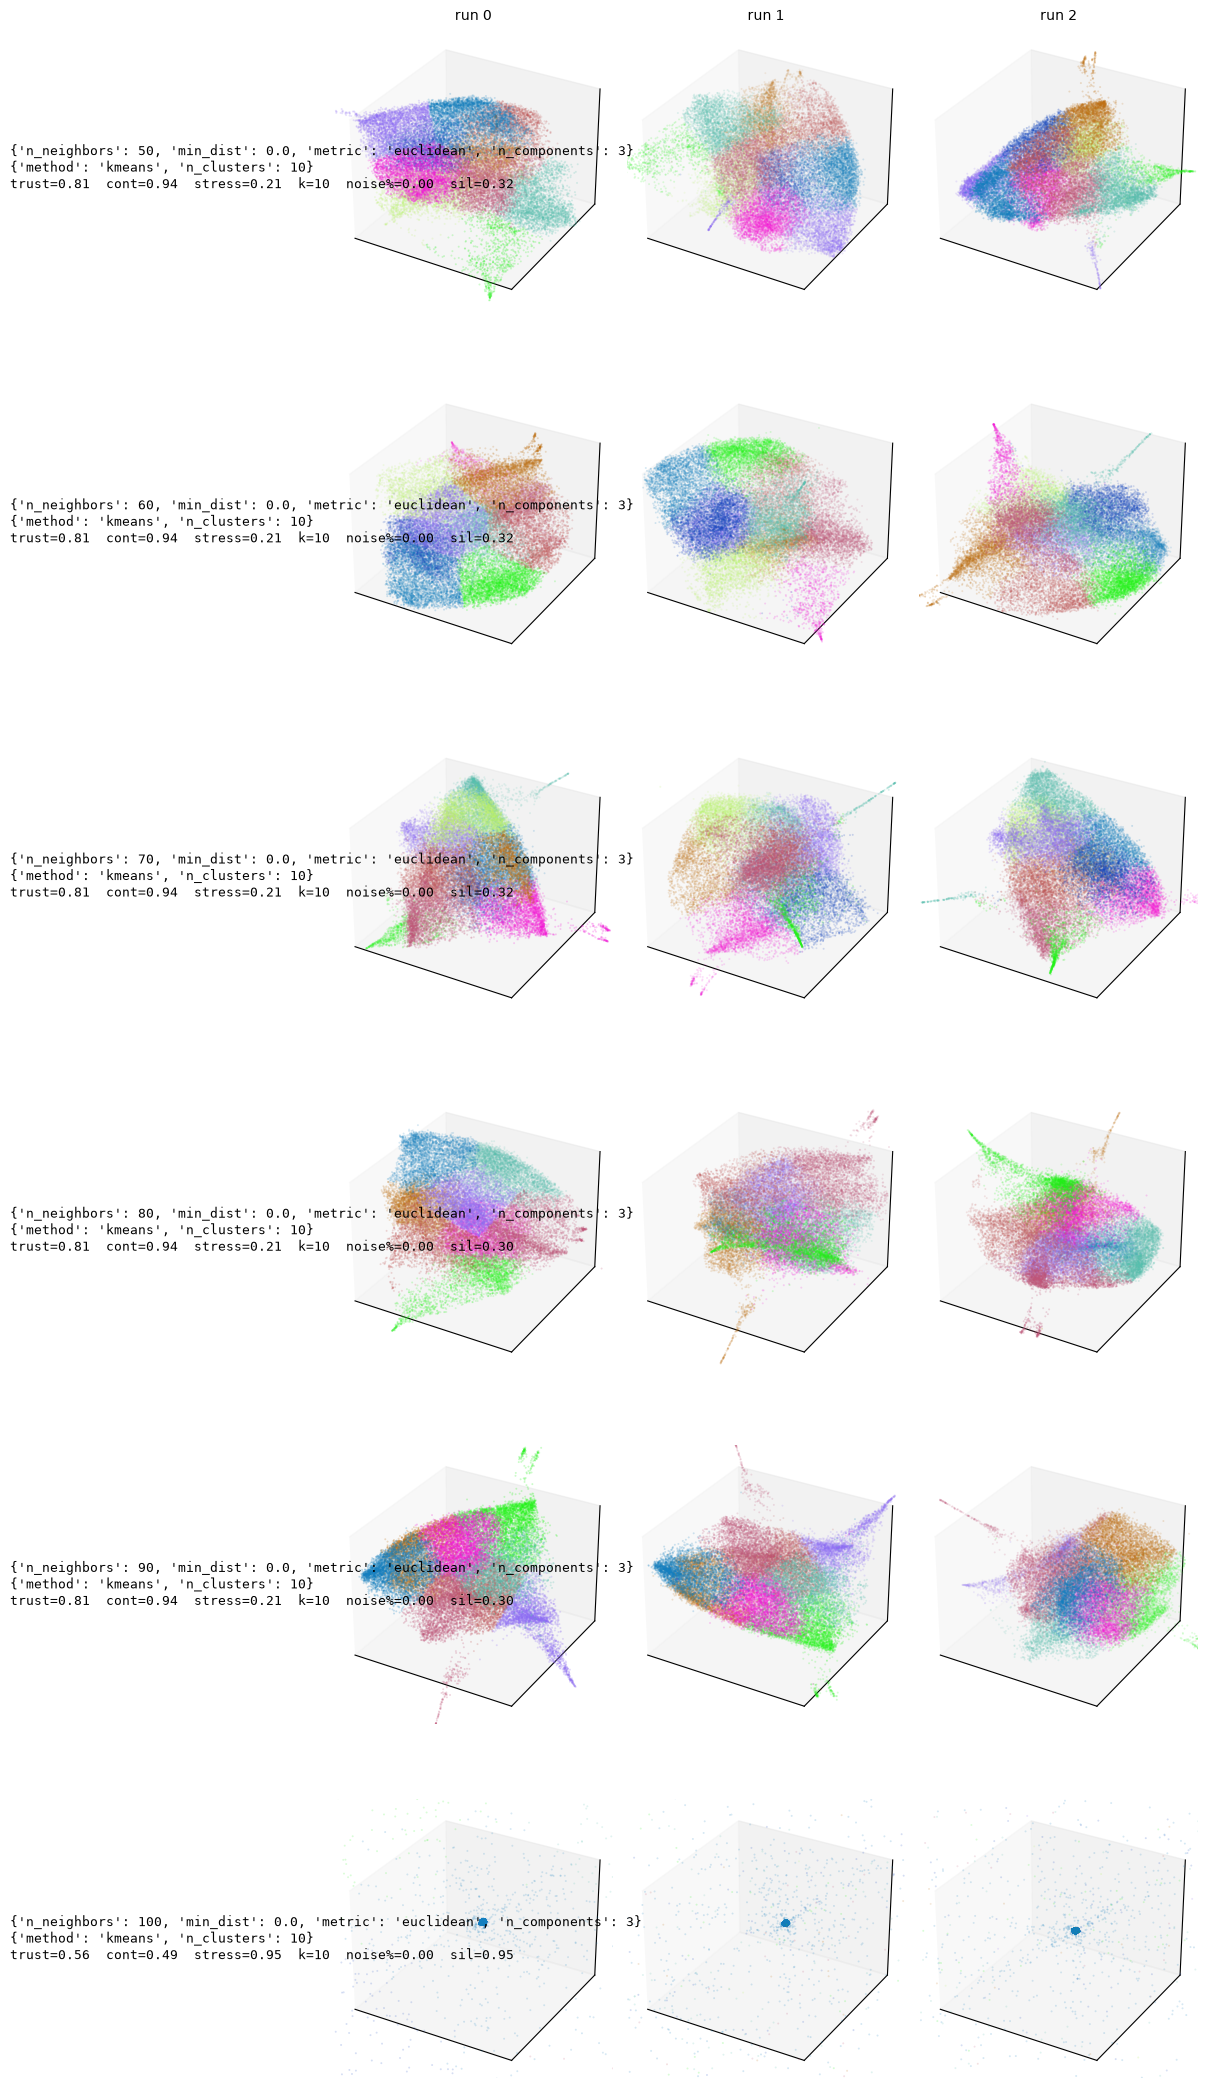

,n_neighbors,min_dist,metric,n_components,method,n_clusters,trustworthiness,continuity,normalized_stress,noise_%,silhouette
0,50,0.0,euclidean,3,kmeans,10,0.812,0.935,0.212,0.0,0.322
1,60,0.0,euclidean,3,kmeans,10,0.809,0.935,0.213,0.0,0.317
2,70,0.0,euclidean,3,kmeans,10,0.813,0.935,0.214,0.0,0.321
3,80,0.0,euclidean,3,kmeans,10,0.811,0.937,0.209,0.0,0.302
4,90,0.0,euclidean,3,kmeans,10,0.812,0.936,0.209,0.0,0.302
5,100,0.0,euclidean,3,kmeans,10,0.563,0.485,0.949,0.0,0.952


In [9]:
#KMEANS 

UMAP_GRID = {"n_neighbors": [50,60,70,80,90,100], "min_dist": [0.0], "metric": ["euclidean"], "n_components":[3]}
CLUSTERING_GRID = {"method": ["kmeans"], "n_clusters": [10]}

results, panels = run_embedding_sweep(patches, UMAP_GRID, CLUSTERING_GRID,
                                      n_runs=3, sweep_size=None, field=None, silhouette=True)
stats = show_embedding_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

GPU 1.94
embedding {'n_neighbors': 57, 'min_dist': 0.0, 'metric': 'euclidean', 'n_components': 3}
[2026-07-29 22:57:13.308] [CUML] [info] Building knn graph using nn descent
[2026-07-29 22:57:15.544] [CUML] [warning] Spectral initialization failed, using random initialization instead.
[2026-07-29 22:57:17.190] [CUML] [info] Building knn graph using nn descent
[2026-07-29 22:57:19.348] [CUML] [warning] Spectral initialization failed, using random initialization instead.
[2026-07-29 22:57:20.958] [CUML] [info] Building knn graph using nn descent
[2026-07-29 22:57:23.119] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Clustering | device=gpu | {'method': 'dbscan', 'eps': 0.05, 'min_samples': 4}
[2026-07-29 22:57:26.387] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 65453 -> 10324. Using the larger integer type might result in better performance
Clusters found: 6169
  {'method': 'dbscan', 'eps': 0.05, 'min_samples': 4}  min_di

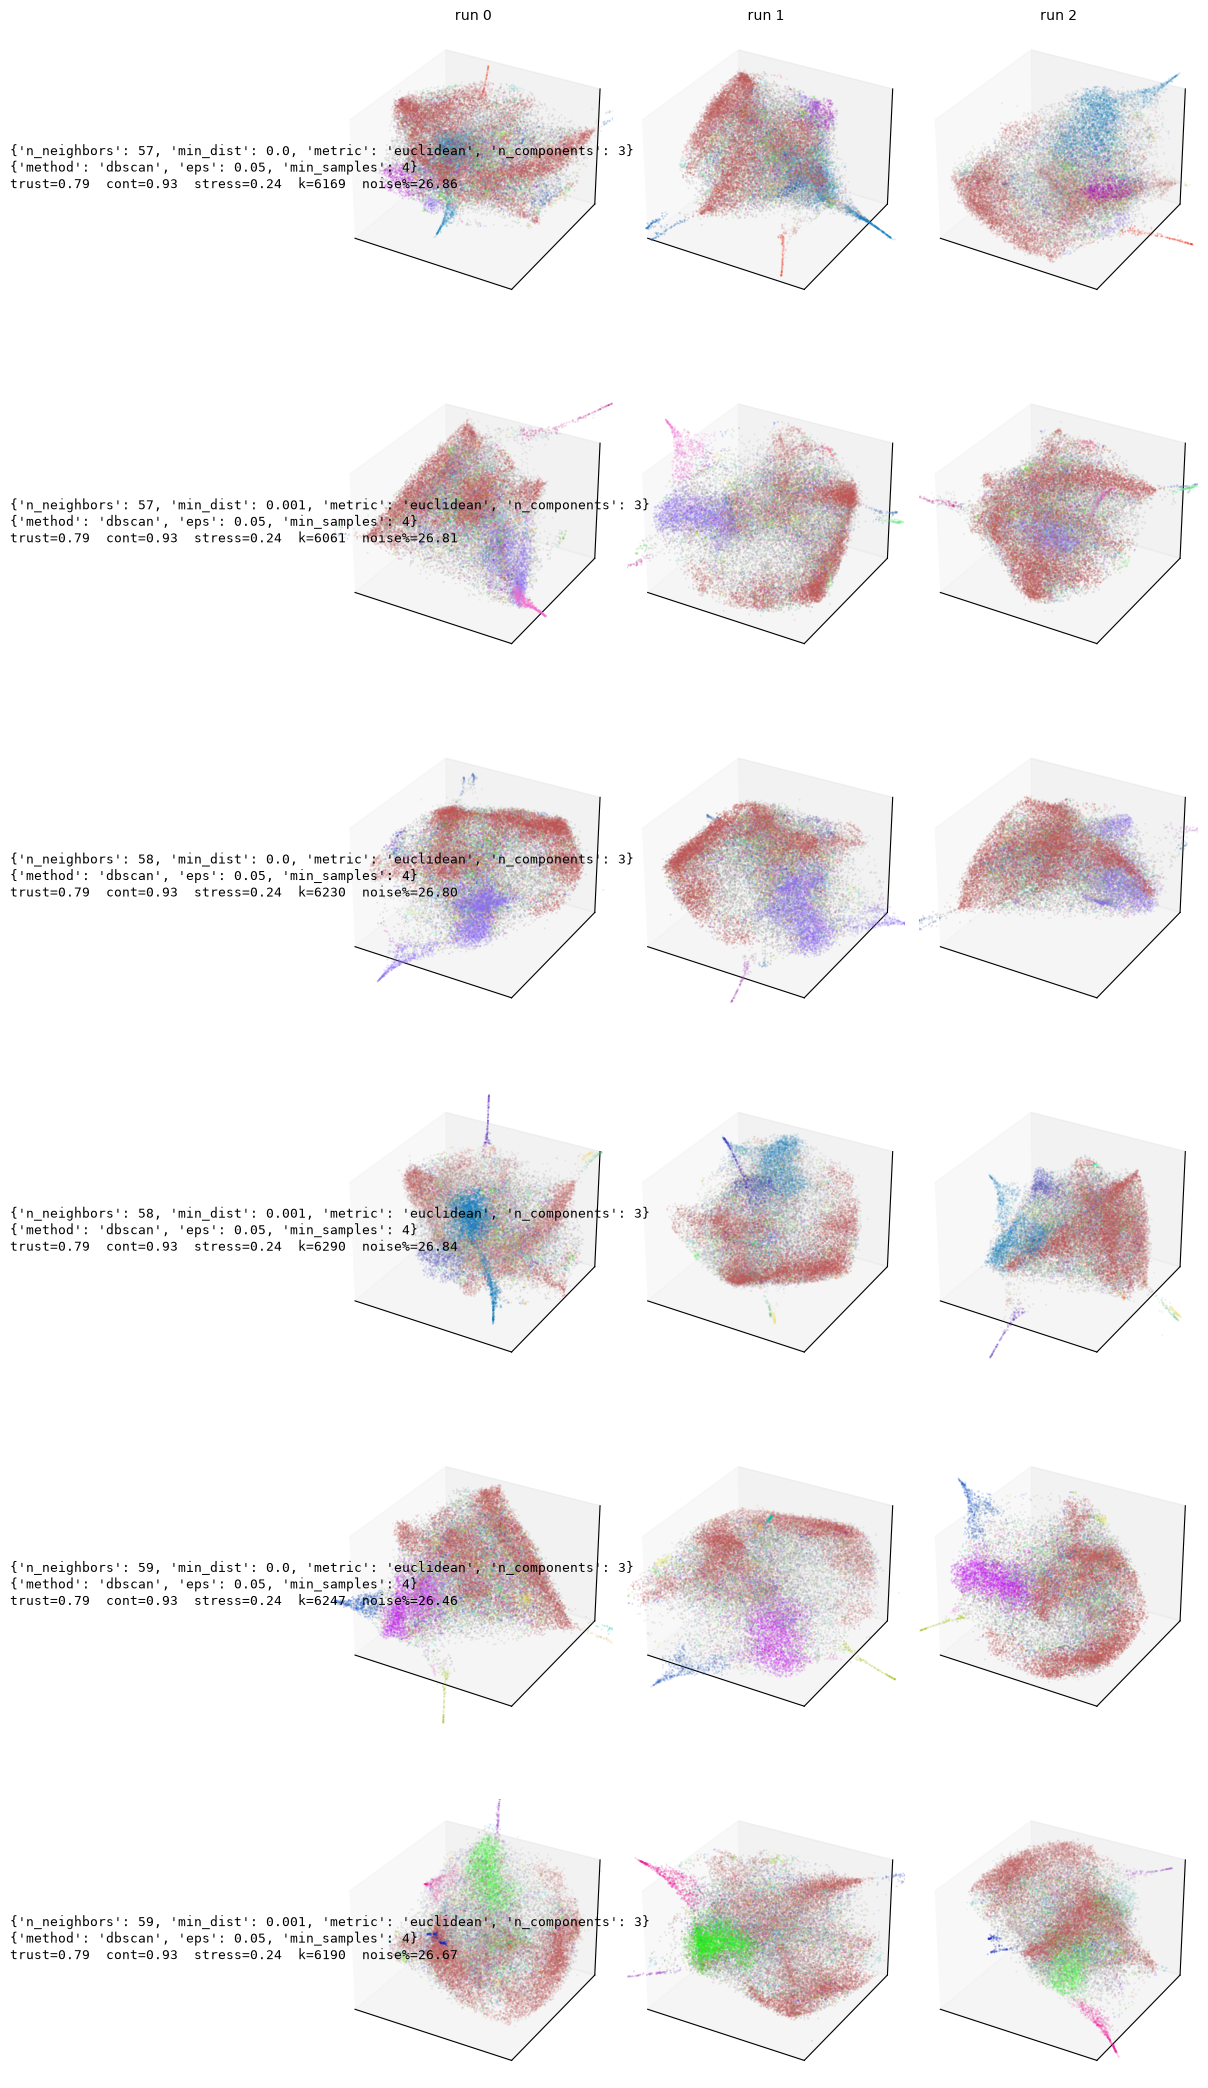

,n_neighbors,min_dist,metric,n_components,method,eps,min_samples,trustworthiness,continuity,normalized_stress,n_clusters,noise_%
0,57,0.000,euclidean,3,dbscan,0.05,4,0.789,0.925,0.242,6169,26.863
1,57,0.001,euclidean,3,dbscan,0.05,4,0.789,0.926,0.241,6061,26.813
2,58,0.000,euclidean,3,dbscan,0.05,4,0.791,0.926,0.242,6230,26.801
3,58,0.001,euclidean,3,dbscan,0.05,4,0.789,0.925,0.242,6290,26.845
4,59,0.000,euclidean,3,dbscan,0.05,4,0.789,0.926,0.243,6247,26.462
5,59,0.001,euclidean,3,dbscan,0.05,4,0.788,0.925,0.243,6190,26.667


In [14]:
UMAP_GRID = {"n_neighbors": [57, 58, 59], "min_dist": [0.0, 0.001], "metric": ["euclidean"], "n_components":[3]}
CLUSTERING_GRID = {"method": ["dbscan"], "eps": [0.05], "min_samples": [4]}

results, panels = run_embedding_sweep(patches, UMAP_GRID, CLUSTERING_GRID,
                                      n_runs=3, sweep_size=None, field=None)
stats = show_embedding_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

GPU 1.94
embedding {'n_neighbors': 57, 'min_dist': 0.0, 'metric': 'euclidean', 'n_components': 3}
[2026-07-29 23:08:54.912] [CUML] [info] Building knn graph using nn descent
[2026-07-29 23:08:57.132] [CUML] [warning] Spectral initialization failed, using random initialization instead.
[2026-07-29 23:08:58.799] [CUML] [info] Building knn graph using nn descent
[2026-07-29 23:09:00.976] [CUML] [warning] Spectral initialization failed, using random initialization instead.
[2026-07-29 23:09:02.575] [CUML] [info] Building knn graph using nn descent
[2026-07-29 23:09:04.732] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Clustering | device=gpu | {'method': 'dbscan', 'eps': 0.065, 'min_samples': 7}
[2026-07-29 23:09:08.047] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 65453 -> 10324. Using the larger integer type might result in better performance
Clusters found: 1606
  {'method': 'dbscan', 'eps': 0.065, 'min_samples': 7}  min_

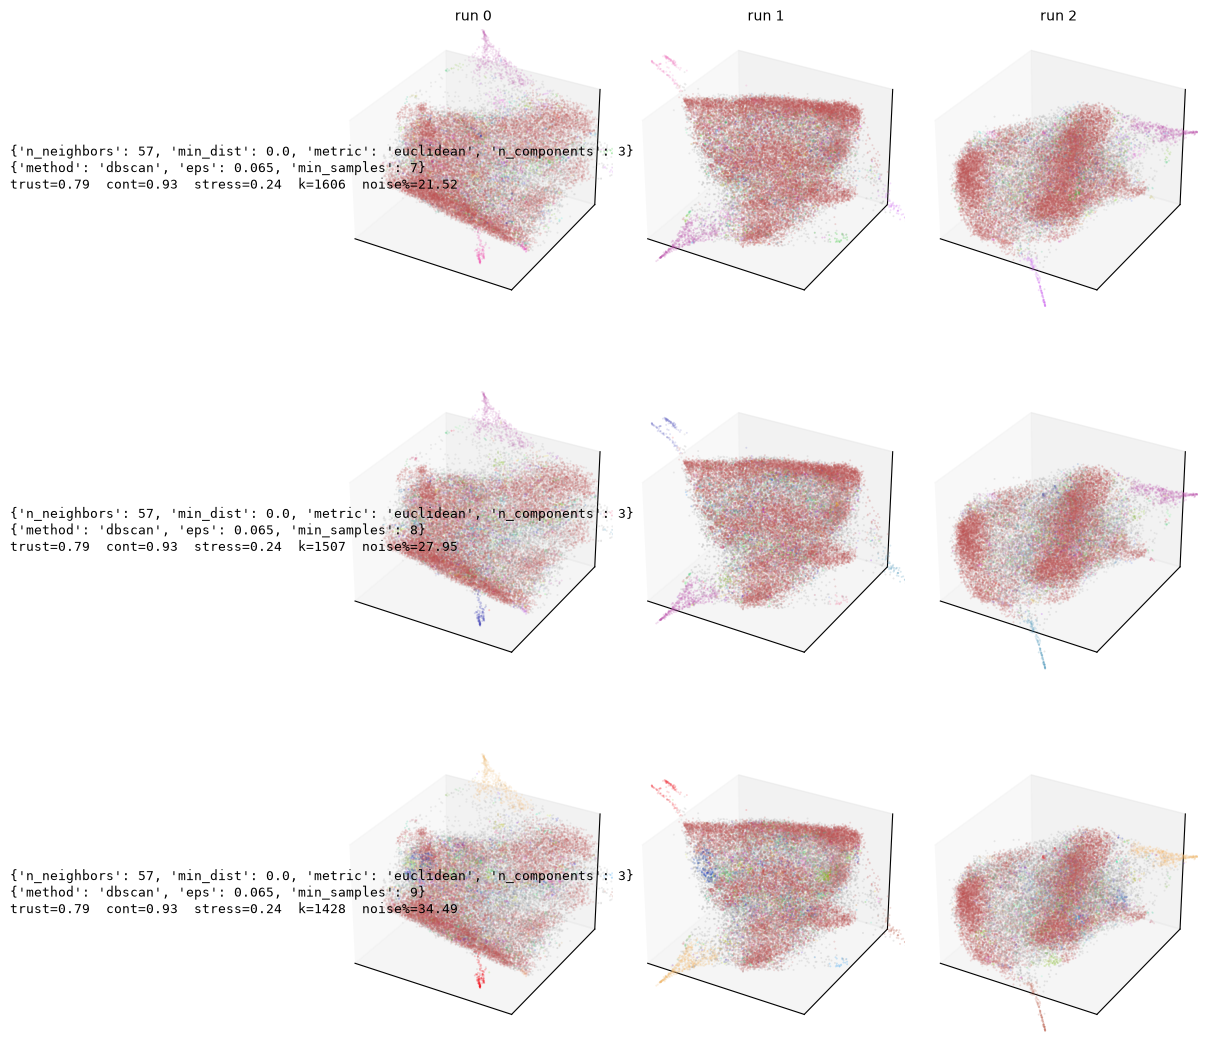

,n_neighbors,min_dist,metric,n_components,method,eps,min_samples,trustworthiness,continuity,normalized_stress,n_clusters,noise_%
0,57,0.0,euclidean,3,dbscan,0.065,7,0.789,0.926,0.242,1606,21.518
1,57,0.0,euclidean,3,dbscan,0.065,8,0.789,0.926,0.242,1507,27.953
2,57,0.0,euclidean,3,dbscan,0.065,9,0.789,0.926,0.242,1428,34.494


In [17]:
# UMAP_GRID = {"n_neighbors": [5, 15, 50, 100, 200], "min_dist": [0.0, 0.01, 0.05], "metric": ["euclidean", "cosine"], "n_components":[3,10,25]}
# CLUSTERING_GRID = {"method": ["dbscan"], "min_cluster_size": [20],
#                    "min_samples": [None]}


UMAP_GRID = {"n_neighbors": [57], "min_dist": [0.0], "metric": ["euclidean"], "n_components":[3]}
CLUSTERING_GRID = {"method": ["dbscan"], "eps": [0.065], "min_samples": [7,8,9]}

results, panels = run_embedding_sweep(patches, UMAP_GRID, CLUSTERING_GRID,
                                      n_runs=3, sweep_size=None, field=None)
stats = show_embedding_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

GPU 1.98
embedding {'n_neighbors': 30, 'min_dist': 0.0, 'metric': 'euclidean', 'n_components': 3}
[2026-07-29 23:27:54.586] [CUML] [info] Building knn graph using nn descent
[2026-07-29 23:27:56.589] [CUML] [warning] Spectral initialization failed, using random initialization instead.
[2026-07-29 23:27:57.928] [CUML] [info] Building knn graph using nn descent
[2026-07-29 23:27:59.919] [CUML] [warning] Spectral initialization failed, using random initialization instead.
[2026-07-29 23:28:01.290] [CUML] [info] Building knn graph using nn descent
[2026-07-29 23:28:03.283] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 2, 'min_samples': None}
Clusters found: 31321
  {'method': 'hdbscan', 'min_cluster_size': 2, 'min_samples': None}  min_dist=0.000  trustworthiness=0.790  continuity=0.925  normalized_stress=0.239  noise_%=28.087
Clustering | device=gpu | {'method': 'hdbscan', 'min_clust

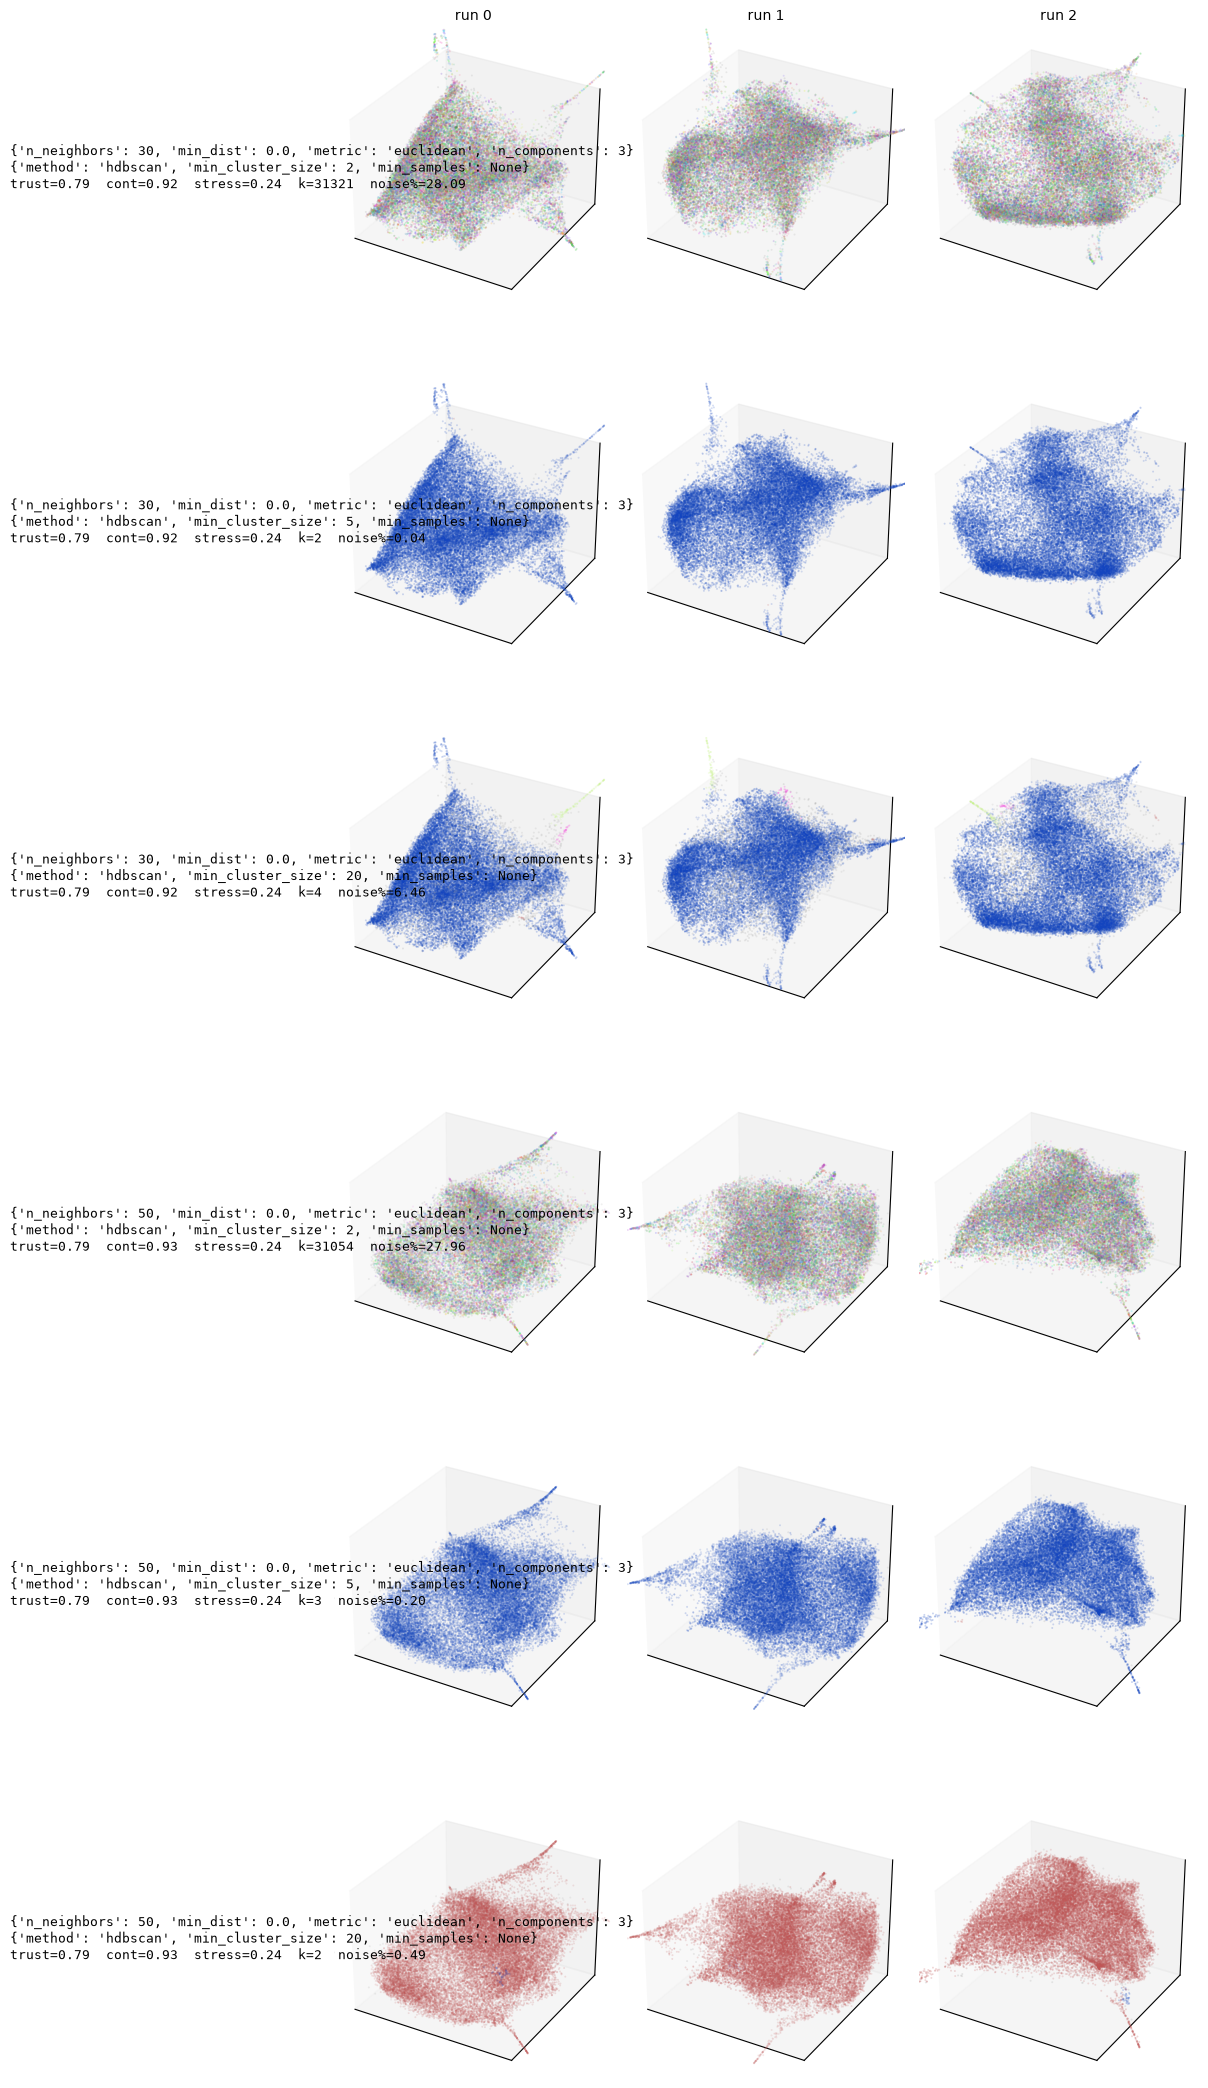

,n_neighbors,min_dist,metric,n_components,method,min_cluster_size,min_samples,trustworthiness,continuity,normalized_stress,n_clusters,noise_%
0,30,0.0,euclidean,3,hdbscan,2,None,0.790,0.925,0.239,31321,28.087
1,30,0.0,euclidean,3,hdbscan,5,None,0.790,0.925,0.239,2,0.042
2,30,0.0,euclidean,3,hdbscan,20,None,0.790,0.925,0.239,4,6.459
3,50,0.0,euclidean,3,hdbscan,2,None,0.788,0.925,0.240,31054,27.962
4,50,0.0,euclidean,3,hdbscan,5,None,0.788,0.925,0.240,3,0.198
5,50,0.0,euclidean,3,hdbscan,20,None,0.788,0.925,0.240,2,0.493


In [21]:
UMAP_GRID = {"n_neighbors": [30, 50], "min_dist": [0.0], "metric": ["euclidean"], "n_components":[3]}
CLUSTERING_GRID = {"method": ["hdbscan"], "min_cluster_size": [2,5,20], "min_samples": [None]}

results, panels = run_embedding_sweep(patches, UMAP_GRID, CLUSTERING_GRID,
                                      n_runs=3, sweep_size=None, field=None)
stats = show_embedding_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

# Sweep with clustering

In [ ]:
def run_umap_sweep(patches, umap_grid, clustering, *,
                   n_members=3, n_components=3, device="gpu",
                   sweep_size=50000, display_subsample=30000,
                   save_path="sweep_results.pkl", seed=0, verbose=True):
    """Sweep UMAP params; per combo run an HDBSCAN ensemble and collect stats
    plus subsampled embeddings for the review grid.

    patches           : (N_patches, D) feature matrix to cluster.
    umap_grid         : {umap_param: [values, ...]} — swept full-factorial.
    clustering        : fixed clustering_dict passed to every NEMI run.
    n_members         : ensemble members per combo.
    n_components      : UMAP output dims.
    sweep_size        : patches per fit (subsample for speed/GPU memory; None = all).
    display_subsample : points kept per embedding panel (None = all).
    save_path         : pickle written after each combo so a crash is resumable.

    Returns (results, panels).  Results align to the subsampled patches — use them
    to rank configs, then re-run the winner on the full patch set.
    """
    rng = np.random.default_rng(seed)
    sweep_idx = (rng.choice(len(patches), size=sweep_size, replace=False)
                 if sweep_size and sweep_size < len(patches) else slice(None))
    sweep_patches = patches[sweep_idx]

    results, panels = [], []
    for umap_params in _umap_configs(umap_grid):
        if verbose:
            print(f"GPU {gpu_used_gb():.2f} GB | host {host_used_gb():.2f} GB | {umap_params}")
        try:
            embedding_dict = {"n_components": n_components, **umap_params}
            nemi = NEMI(params={"device": device,
                                "embedding_dict": embedding_dict,
                                "clustering_dict": clustering})
            nemi.run(sweep_patches, n=n_members, assess_overlap=True)

            clusters, embedding = nemi.clusters, nemi.embedding
            entropy, unassigned = nemi.entropy, nemi.unassigned_frac
            member_counts = [_n_clusters(m.clusters) for m in nemi.nemi_pack]

            stat = {**umap_params,
                    "entropy":           float(np.nanmean(entropy)),
                    "member_abstain_%":  100 * float(np.mean(unassigned)),
                    "consensus_noise_%": 100 * float(np.mean(clusters == -1)),
                    "consensus_k":       _n_clusters(clusters),
                    "member_k_min":      min(member_counts),
                    "member_k_max":      max(member_counts),
                    "member_k_std":      float(np.std(member_counts))}

            if verbose:
                print("=" * 72)
                print(f"UMAP {umap_params}   |   {clustering}")
                print(f"  overall entropy       : {stat['entropy']:.3f}")
                print(f"  member-abstain %      : {stat['member_abstain_%']:.1f}")
                print(f"  consensus-noise %     : {stat['consensus_noise_%']:.1f}")
                print(f"  consensus k           : {stat['consensus_k']}")
                print(f"  per-member k (spread) : {member_counts}  "
                      f"min={stat['member_k_min']} max={stat['member_k_max']} std={stat['member_k_std']:.1f}")

            disp = (rng.choice(len(clusters), size=min(len(clusters), display_subsample), replace=False)
                    if display_subsample else slice(None))
            panels.append({"title": str(umap_params), "emb": np.asarray(embedding)[disp],
                           "clusters": clusters[disp], "entropy": entropy[disp],
                           "unassigned": unassigned[disp]})
            results.append(stat)

            if save_path:
                with open(save_path, "wb") as f:
                    pickle.dump({"results": results, "panels": panels}, f)
        except Exception as e:
            print(f"  !! failed on {umap_params}: {type(e).__name__}: {e}")
        finally:
            nemi = None
            _free_gpu()

    return results, panels

In [ ]:
def show_sweep(results, panels, *, dims=3, sort_by=None, clip_pct=1.0):
    """Review grid (rows = runs; cols = clusters / entropy / unassigned), then a
    stats table.  clip_pct clips each axis to that percentile range to ignore
    outliers (0 = off)."""
    proj    = "3d" if dims == 3 else None
    headers = ["clusters", "entropy", "unassigned"]

    def _frame(ax, pts):
        if clip_pct <= 0:
            return
        setters = [ax.set_xlim, ax.set_ylim] + ([ax.set_zlim] if dims == 3 else [])
        for d, setlim in enumerate(setters):
            lo, hi = np.percentile(pts[:, d], [clip_pct, 100 - clip_pct])
            if hi > lo:
                setlim(lo, hi)

    def _title(p, res):
        return (f"{p['title']}\n"
                f"H={res['entropy']:.2f}  abstain={res['member_abstain_%']:.0f}%  "
                f"noise={res['consensus_noise_%']:.0f}%  k={res['consensus_k']}  "
                f"member_k[{res['member_k_min']}-{res['member_k_max']}]")

    def _scatter(ax, e, c, cmap, norm=None):
        s = ax.scatter(*[e[:, i] for i in range(dims)], c=c, cmap=cmap, norm=norm,
                       s=2, alpha=0.5, linewidths=0)
        _frame(ax, e)
        return s

    # --- review grid ---
    n = len(panels)
    fig, axes = plt.subplots(n, 3, figsize=(16, 5 * n), squeeze=False,
                             subplot_kw={"projection": proj})
    fig.subplots_adjust(left=0.24, hspace=0.25, wspace=0.15)

    for r, (p, res) in enumerate(zip(panels, results)):
        e = p["emb"]
        cmap_c, norm_c = vis._cluster_cmap_norm(p["clusters"])          # discrete, -1 grey
        _scatter(axes[r, 0], e, p["clusters"], cmap_c, norm_c)
        sc1 = _scatter(axes[r, 1], e, p["entropy"], "viridis")
        sc2 = _scatter(axes[r, 2], e, p["unassigned"], "magma")
        fig.colorbar(sc1, ax=axes[r, 1], fraction=0.046, pad=0.02)
        fig.colorbar(sc2, ax=axes[r, 2], fraction=0.046, pad=0.02)
        if r == 0:
            for j in range(3):
                axes[r, j].set_title(headers[j])
        pos = axes[r, 0].get_position()
        fig.text(0.02, pos.y0 + pos.height / 2, _title(p, res),
                 ha="left", va="center", fontsize=9, family="monospace")
    plt.show()

    # --- stats table (no images) ---
    df = pd.DataFrame(results)
    if sort_by and sort_by in df.columns:
        df = df.sort_values(sort_by).reset_index(drop=True)
    display(df.round(3))
    return df

In [31]:
N_MEMBERS = 5
EMBEDDING_DIMENSIONS = 3
DISPLAY_DIMS = 3
DISPLAY_SUBSAMPLE = 30000        # points per scatter (None = plot all)

# fixed HDBSCAN params for every run
CLUSTERING = {"method": "hdbscan", "min_cluster_size": 400, "min_samples": None}

# sweep
UMAP_GRID = {
    "n_neighbors": [2, 50],
    "min_dist":    [0.0, 0.1], 
    "metric":      ["euclidean", "cosine"]
}

# UMAP_GRID = {
#     "n_neighbors": [2, 15, 50],
#     "min_dist":    [0.0, 0.1], 
#     "metric":      ["euclidean", "cosine"]
# }

results, panels = run_umap_sweep(patches, UMAP_GRID, CLUSTERING,
                                 n_members=3, n_components=EMBEDDING_DIMENSIONS,
                                 sweep_size=None)

GPU 1.86 GB | host 5.70 GB | {'n_neighbors': 2, 'min_dist': 0.0, 'metric': 'euclidean'}


  0%|          | 0/3 [00:00<?, ?it/s]

Fitting the embedding
[2026-07-23 22:51:24.359] [CUML] [info] Building knn graph using nn descent
[2026-07-23 22:51:28.765] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


 33%|███▎      | 1/3 [00:20<00:41, 20.72s/it]

Clusters found: 3
Sorting clusters
Fitting the embedding
[2026-07-23 22:51:44.182] [CUML] [info] Building knn graph using nn descent
[2026-07-23 22:51:48.617] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


...

Clusters found: 2
Sorting clusters
Fitting the embedding
[2026-07-23 22:59:07.879] [CUML] [info] Building knn graph using nn descent
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


 67%|██████▋   | 2/3 [00:41<00:20, 20.51s/it]

Clusters found: 2
Sorting clusters
Fitting the embedding
[2026-07-23 22:59:28.286] [CUML] [info] Building knn graph using nn descent
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


100%|██████████| 3/3 [01:01<00:00, 20.40s/it]

Clusters found: 3
Sorting clusters
3 3
UMAP {'n_neighbors': 50, 'min_dist': 0.1, 'metric': 'cosine'}   |   {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}
  overall entropy       : 0.037
  member-abstain %      : 3.5
  consensus-noise %     : 2.5
  consensus k           : 3
  per-member k (spread) : [2, 2, 3]  min=2 max=3 std=0.5


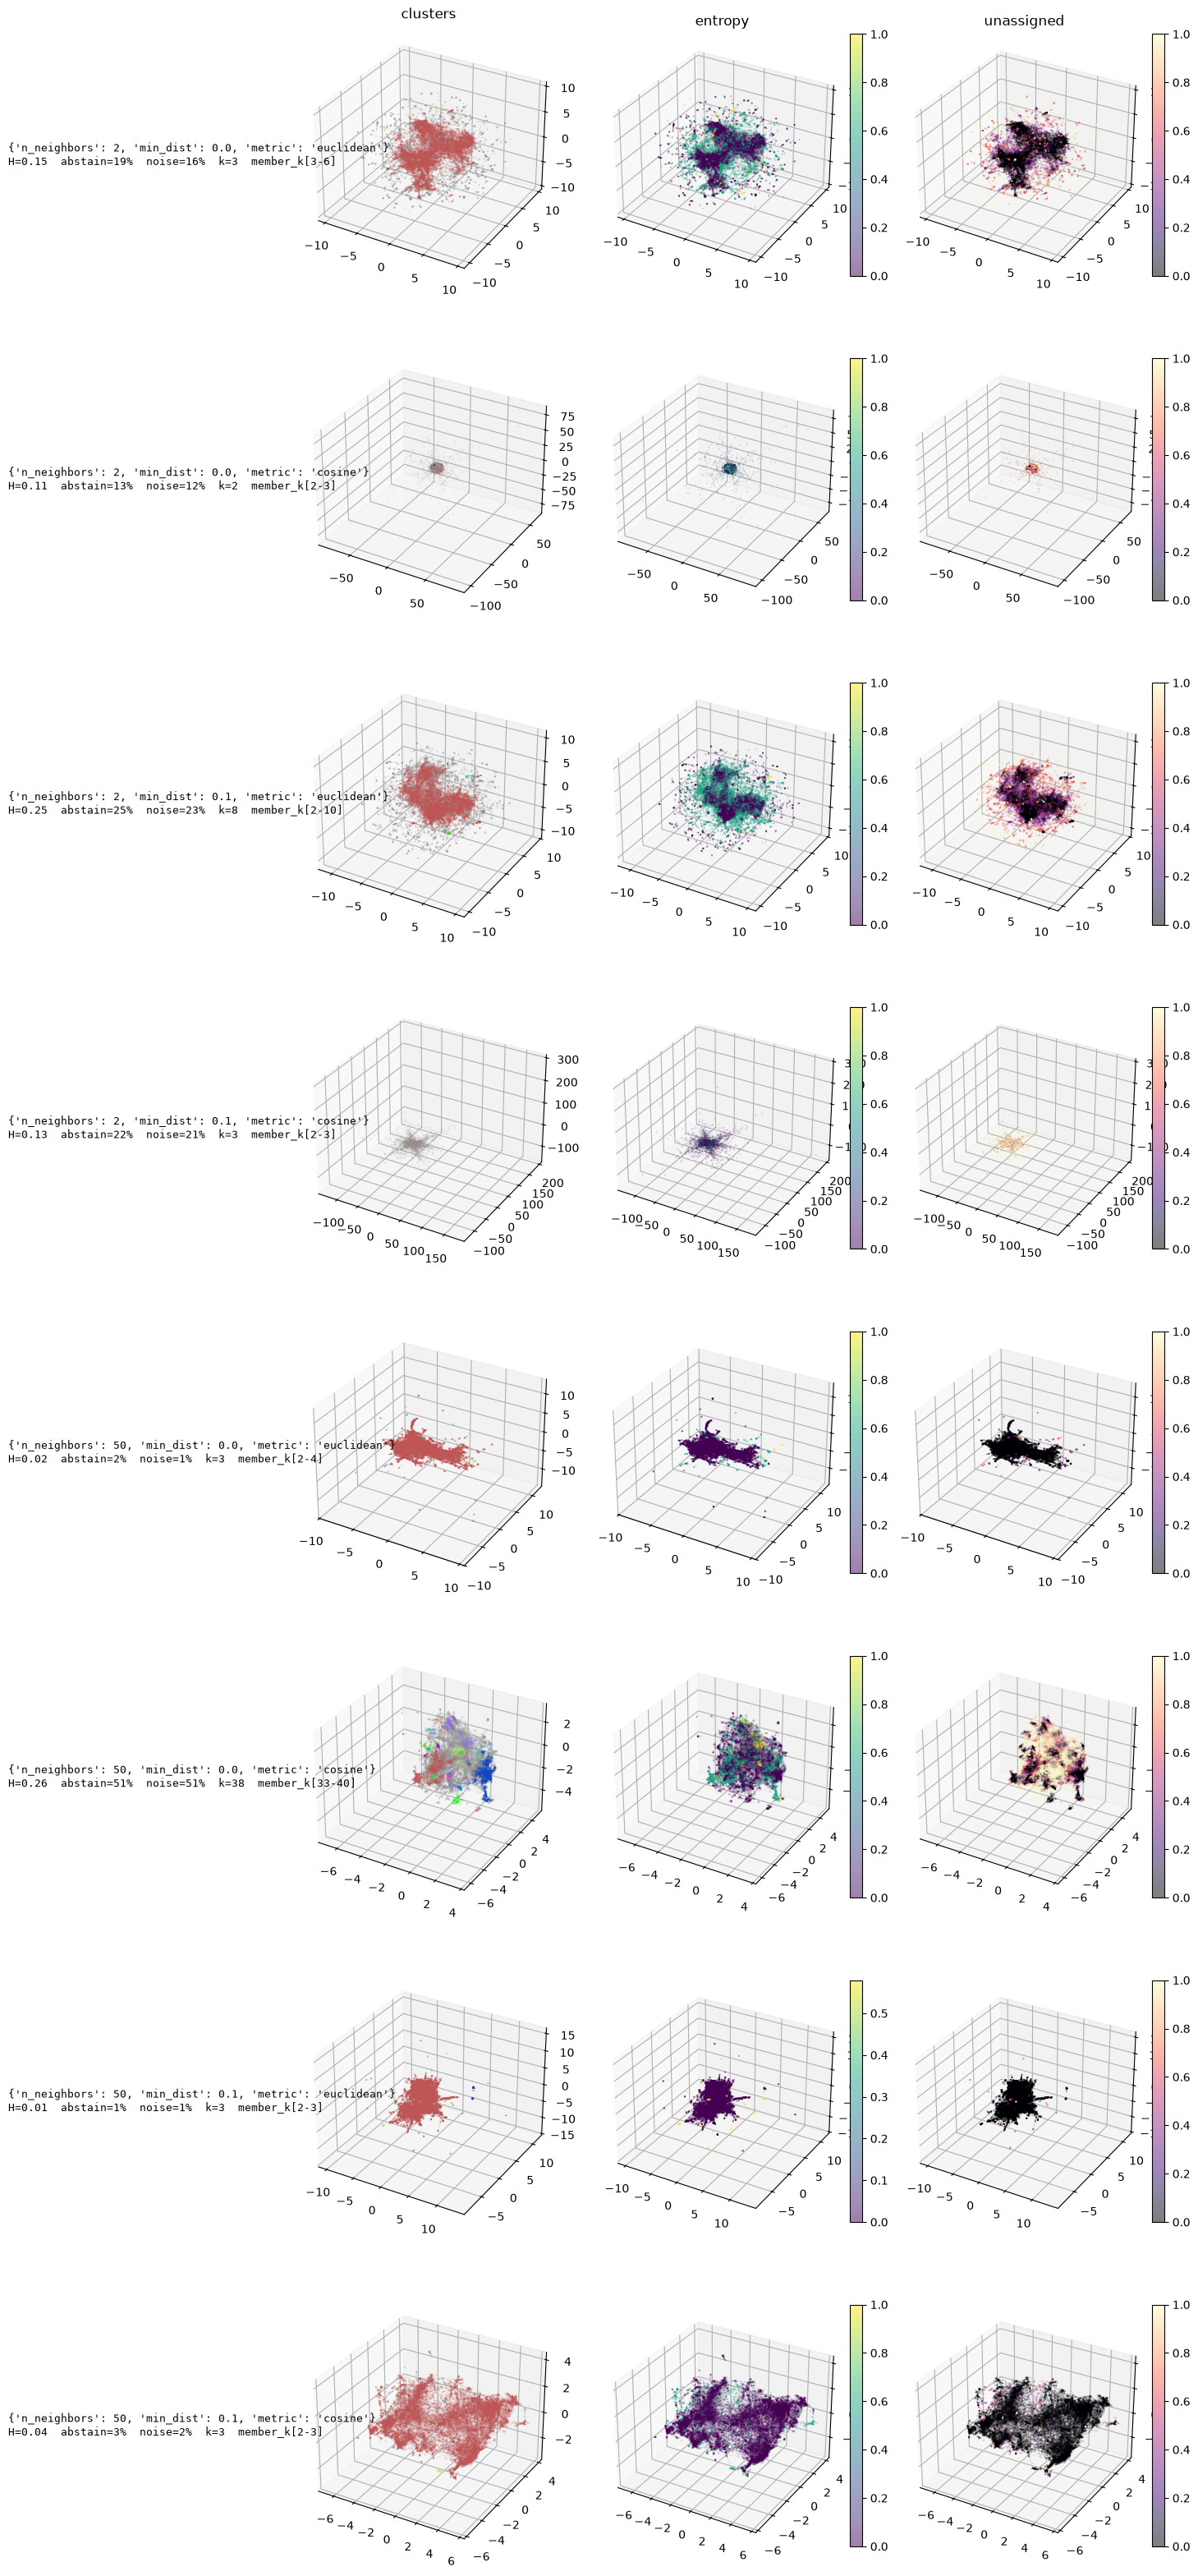

,n_neighbors,min_dist,metric,entropy,member_abstain_%,consensus_noise_%,consensus_k,member_k_min,member_k_max,member_k_std
0,2,0.0,euclidean,0.154,18.998,16.425,3,3,6,1.247
1,2,0.0,cosine,0.115,12.889,11.593,2,2,3,0.471
2,2,0.1,euclidean,0.248,25.438,22.862,8,2,10,3.399
3,2,0.1,cosine,0.130,22.306,20.895,3,2,3,0.471
4,50,0.0,euclidean,0.019,1.682,1.188,3,2,4,0.816
5,50,0.0,cosine,0.263,51.279,51.088,38,33,40,2.944
6,50,0.1,euclidean,0.009,1.127,1.257,3,2,3,0.471
7,50,0.1,cosine,0.037,3.461,2.488,3,2,3,0.471


In [32]:
stats = show_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)
# stats is the DataFrame; e.g. stats.sort_values("entropy") or stats.to_csv("sweep1.csv")

In [21]:
# fixed HDBSCAN params for every run
CLUSTERING = {"method": "hdbscan", "min_cluster_size": 400, "min_samples": None}

# sweep
UMAP_GRID = {
    "n_neighbors": [2, 4, 8, 12], #, 100],
    "min_dist":    [0.0], #, 0.5],
    "metric":      ["euclidean"]
}

results, panels = run_umap_sweep(patches, UMAP_GRID, CLUSTERING,
                                 n_members=5, n_components=EMBEDDING_DIMENSIONS,
                                 sweep_size=None)

GPU 2.19 GB | host 4.71 GB | {'n_neighbors': 2, 'min_dist': 0.0, 'metric': 'euclidean'}


  0%|          | 0/5 [00:00<?, ?it/s]

Fitting the embedding
[2026-07-23 19:12:38.113] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:12:42.417] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


 20%|██        | 1/5 [00:17<01:11, 17.99s/it]

Clusters found: 15
Sorting clusters
Fitting the embedding
[2026-07-23 19:12:55.292] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:12:59.627] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


...

 80%|████████  | 4/5 [01:06<00:16, 16.68s/it]

Clusters found: 24
Sorting clusters
Fitting the embedding
[2026-07-23 19:18:06.778] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:18:11.274] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


100%|██████████| 5/5 [01:23<00:00, 16.72s/it]

Clusters found: 30
Sorting clusters


43 43
UMAP {'n_neighbors': 12, 'min_dist': 0.0, 'metric': 'euclidean'}   |   {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}
  overall entropy       : 0.244
  member-abstain %      : 35.7
  consensus-noise %     : 36.7
  consensus k           : 43
  per-member k (spread) : [43, 37, 43, 24, 30]  min=24 max=43 std=7.4


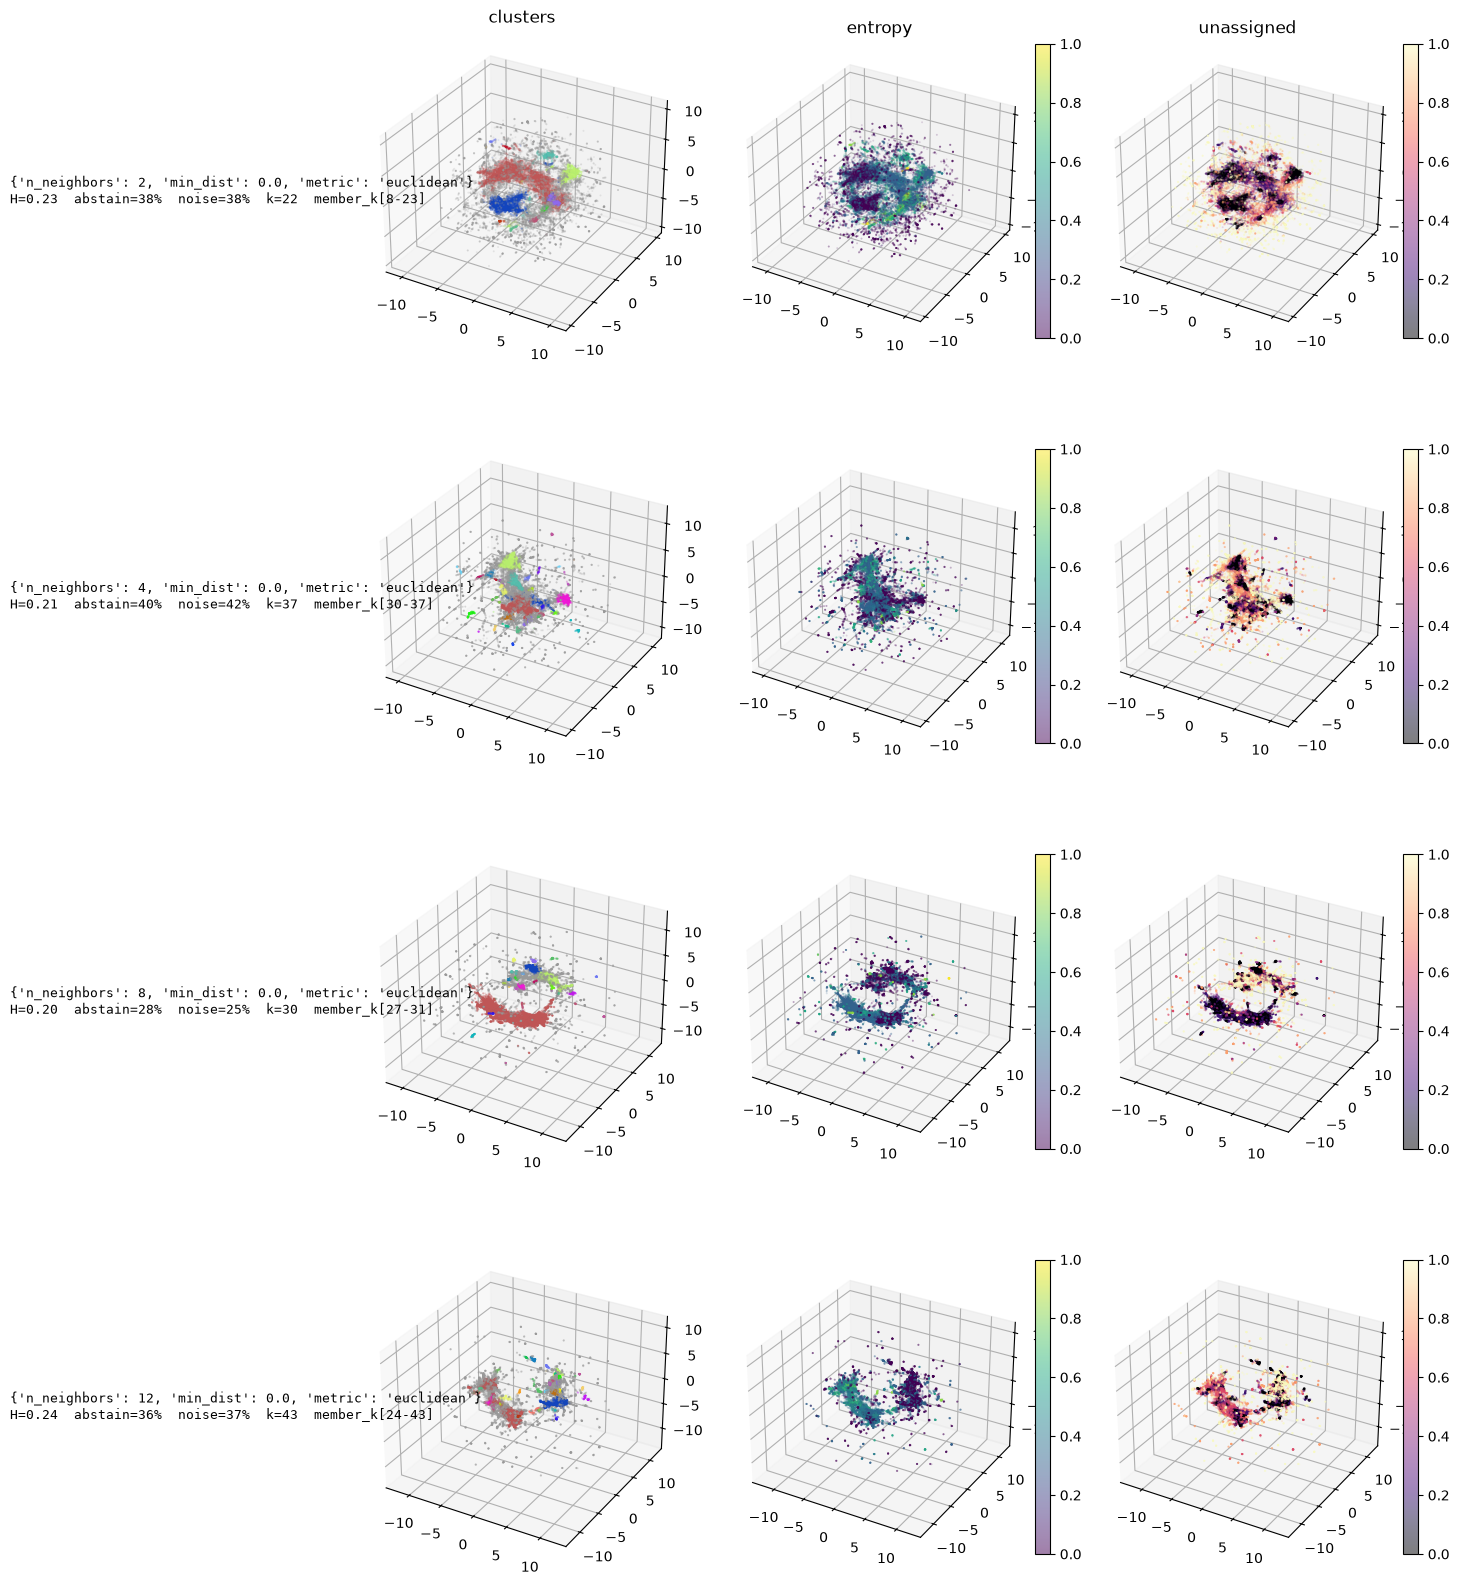

,n_neighbors,min_dist,metric,entropy,member_abstain_%,consensus_noise_%,consensus_k,member_k_min,member_k_max,member_k_std
0,2,0.0,euclidean,0.233,37.821,37.887,22,8,23,5.231
1,4,0.0,euclidean,0.213,39.948,41.961,37,30,37,2.227
2,8,0.0,euclidean,0.204,27.671,24.608,30,27,31,1.625
3,12,0.0,euclidean,0.244,35.711,36.718,43,24,43,7.446


In [22]:
stats = show_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)

In [23]:
# fixed HDBSCAN params for every run
CLUSTERING = {"method": "hdbscan", "min_cluster_size": 400, "min_samples": None}

# sweep
UMAP_GRID = {
    "n_neighbors": [7, 8, 9], #, 100],
    "min_dist":    [0.0, 0.05, 0.1], #, 0.5],
    "metric":      ["euclidean"]
}

results, panels = run_umap_sweep(patches, UMAP_GRID, CLUSTERING,
                                 n_members=3, n_components=EMBEDDING_DIMENSIONS,
                                 sweep_size=None)

GPU 1.15 GB | host 4.68 GB | {'n_neighbors': 7, 'min_dist': 0.0, 'metric': 'euclidean'}


  0%|          | 0/5 [00:00<?, ?it/s]

Fitting the embedding
[2026-07-23 19:25:34.646] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:25:38.980] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


 20%|██        | 1/5 [00:16<01:05, 16.32s/it]

Clusters found: 27
Sorting clusters
Fitting the embedding
[2026-07-23 19:25:50.102] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:25:54.532] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


...

 80%|████████  | 4/5 [01:08<00:17, 17.13s/it]

Clusters found: 27
Sorting clusters
Fitting the embedding
[2026-07-23 19:40:08.920] [CUML] [info] Building knn graph using nn descent
[2026-07-23 19:40:13.443] [CUML] [warning] Spectral initialization failed, using random initialization instead.
Predicting the clusters
Clustering | device=gpu | {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}


100%|██████████| 5/5 [01:25<00:00, 17.17s/it]

Clusters found: 25
Sorting clusters


34 34
UMAP {'n_neighbors': 9, 'min_dist': 0.1, 'metric': 'euclidean'}   |   {'method': 'hdbscan', 'min_cluster_size': 400, 'min_samples': None}
  overall entropy       : 0.294
  member-abstain %      : 24.6
  consensus-noise %     : 22.9
  consensus k           : 34
  per-member k (spread) : [23, 34, 8, 27, 25]  min=8 max=34 std=8.5


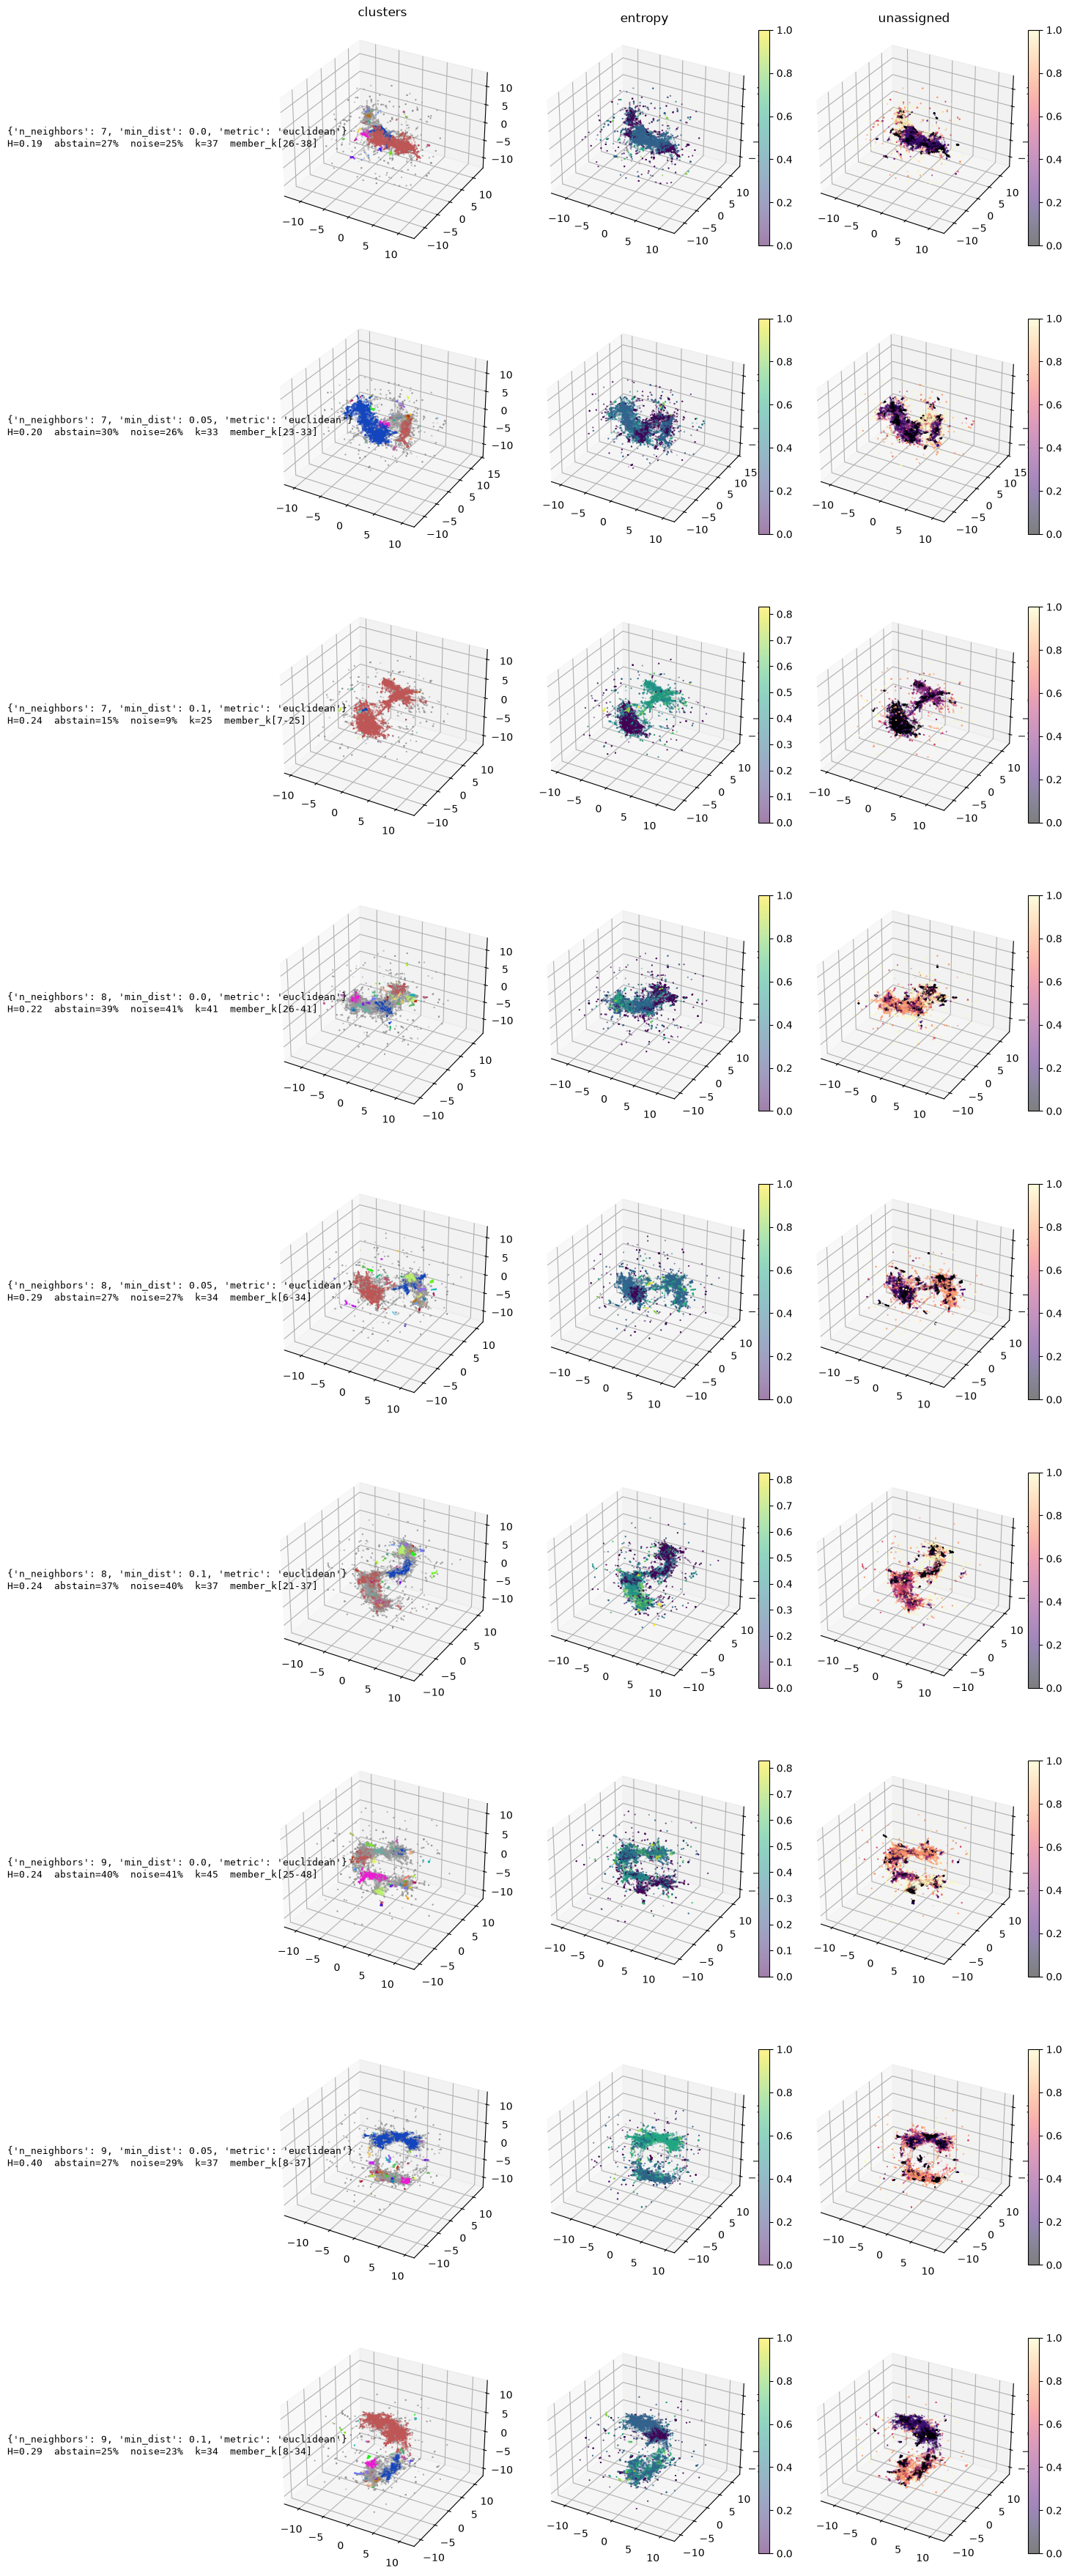

,n_neighbors,min_dist,metric,entropy,member_abstain_%,consensus_noise_%,consensus_k,member_k_min,member_k_max,member_k_std
0,7,0.00,euclidean,0.190,27.274,24.875,37,26,38,4.400
1,7,0.05,euclidean,0.205,29.895,26.016,33,23,33,3.847
2,7,0.10,euclidean,0.237,14.730,9.030,25,7,25,7.823
3,8,0.00,euclidean,0.218,39.126,41.397,41,26,41,5.492
4,8,0.05,euclidean,0.294,26.546,27.084,34,6,34,9.156
5,8,0.10,euclidean,0.236,37.099,39.696,37,21,37,5.987
6,9,0.00,euclidean,0.241,39.614,41.419,45,25,48,7.965
7,9,0.05,euclidean,0.404,27.332,29.245,37,8,37,9.790
8,9,0.10,euclidean,0.294,24.586,22.945,34,8,34,8.546


In [24]:
stats = show_sweep(results, panels, dims=EMBEDDING_DIMENSIONS)